In [25]:
#Sequential workflow : Start -> Strike_rate : bpb : boundary_percent -> END

In [26]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [27]:
class BatsmanState(TypedDict):
    runs : int
    balls : int
    fours : int
    six : int
    
    Strike_rate : float
    bpb : float
    boundary_percent : float
    summary : str

In [28]:
def calculate_Strike_rate(state : BatsmanState):
    
    Strike_rate = state['runs']/state['balls'] * 100
  #  state['Strike_rate'] = Strike_rate
    
    return {'Strike_rate' : Strike_rate}

In [29]:
def calculate_bpb(state : BatsmanState):
    bpb = state["balls"] / (state["fours"] + state["six"])
  #  state['bpb'] = bpb
    
    return {'bpb' : bpb}

In [30]:
def calculate_boundary_percent(state : BatsmanState):
    boundary_percent = (((state['fours'] * 4) + (state['six'] * 6)) / state['runs'])* 100
  #  state['boundary_percent'] = boundary_percent
    
    return {'boundary_percent' : boundary_percent}

In [31]:
def Summary(state: BatsmanState):

    Summary = f"""
Strike Rate - {state['Strike_rate']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'Summary': Summary}

In [32]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_Strike_rate' , calculate_Strike_rate)
graph.add_node('calculate_bpb' , calculate_bpb)
graph.add_node('calculate_boundary_rate' , calculate_boundary_percent)
graph.add_node('Summary' , Summary)


In [33]:
graph.add_edge(START, 'calculate_Strike_rate')
graph.add_edge(START , 'calculate_bpb')
graph.add_edge(START , 'calculate_boundary_rate')

graph.add_edge('calculate_Strike_rate' , 'Summary')
graph.add_edge('calculate_bpb' ,'Summary')
graph.add_edge('calculate_boundary_rate' ,'Summary')

graph.add_edge('Summary' , END)

workflow = graph.compile()

In [34]:
initial_state = {
    'runs' : 100 ,
    'balls' : 30,
    'fours' : 4 ,
    'six' : 5
} 
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 30,
 'fours': 4,
 'six': 5,
 'Strike_rate': 333.33333333333337,
 'bpb': 3.3333333333333335,
 'boundary_percent': 46.0}

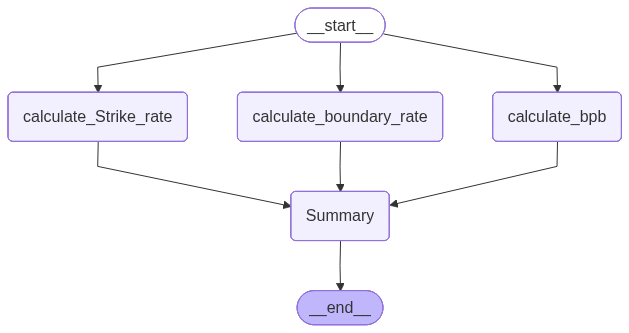

In [35]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())